# **2. EXPLORE AND VISUALIZE DATA**

Read raw data from lakehouse

In [1]:
df = (
    spark.read.option("header", True)
    .option("inferSchema", True)
    .csv("Files/churn/raw/churn.csv")
    .cache()
)

StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 3, Finished, Available, Finished, False)

Create a pandas DataFrame from the Dataset

In [2]:
df = df.toPandas()

StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 4, Finished, Available, Finished, False)

Display raw data

In [3]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette="tab10", rc = {'figure.figsize':(9,6)})
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rc, rcParams
import numpy as np
import pandas as pd
import itertools

StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 5, Finished, Available, Finished, False)

In [4]:
display(df, summary=True)

StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 6, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, c90fb8d1-b373-4254-b85f-62e151355e37)

In [5]:
# Código generado por Data Wrangler para pandas DataFrame

def clean_data(df):
    # Eliminar las filas duplicadas en las columnas: 'RowNumber', 'CustomerId'
    df = df.drop_duplicates(subset=['RowNumber', 'CustomerId'])
    # Quitar filas con datos que faltan en todas las columnas
    df = df.dropna()
    # Eliminar las columnas: 'RowNumber', 'CustomerId', 'Surname'
    df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
    return df

df_clean = clean_data(df.copy())
display(df_clean)

StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 7, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, bb5ca2d3-5e9d-4300-883b-02b6b99f2ee8)

## **EXPLORE THE DATA**

Determine categorical, numerical and target attributes:

In [6]:
dependent_variable_name = "Exited"
print(dependent_variable_name)

categorical_variables = [col for col in df_clean.columns if col in "O"
                        or df_clean[col].nunique() <=5
                        and col not in "Exited"]
print(categorical_variables)

numerical_variables = [col for col in df_clean.columns if df_clean[col].dtype != "object"
                        and df_clean[col].nunique() > 5]
print(numerical_variables)

StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 8, Finished, Available, Finished, False)

Exited
['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']
['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']


## THE FIVE NUMBER SUMMARY
Minimum score, first quartile, median, third quartile and Maximum Score using boxplots

StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 9, Finished, Available, Finished, False)

/tmp/ipykernel_6024/305005624.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


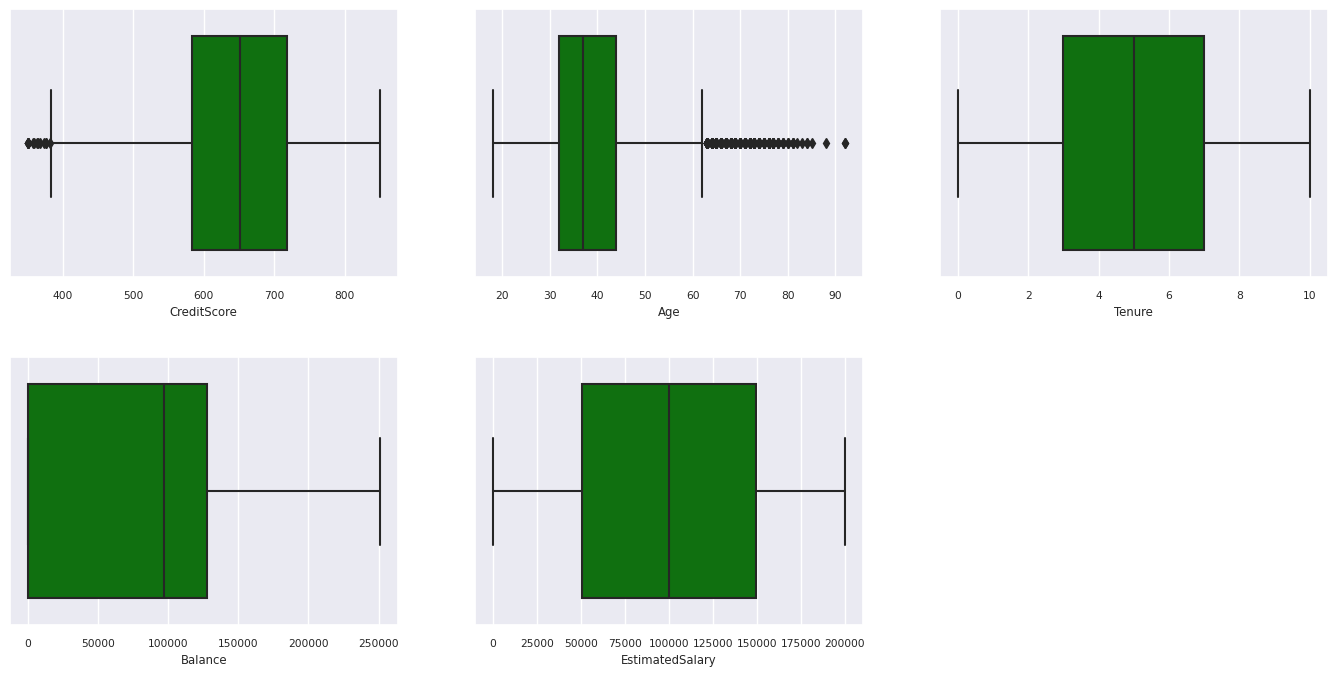

In [7]:
df_num_columns = df_clean[numerical_variables]
sns.set(font_scale = 0.7)

fig, axes = plt.subplots(nrows=2, ncols=3, gridspec_kw=dict(hspace=0.3), figsize = (17,8))
fig.tight_layout()

for ax, col in zip(axes.flatten(), df_num_columns.columns):
    sns.boxplot(x = df_num_columns[col], color='green', ax=ax)
fig.delaxes(axes[1,2])

## DISTRIBUTION OF EXITED AND NONEXITED CUSTOMERS

In [8]:
df_clean['Exited']=df_clean['Exited'].astype(str)

StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 10, Finished, Available, Finished, False)

In [10]:
attr_list = categorical_variables
attr_list.append('Tenure')
print(attr_list)

StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 12, Finished, Available, Finished, False)

['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Tenure']


StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 13, Finished, Available, Finished, False)

0 Geography
1 Gender
2 NumOfProducts
3 HasCrCard
4 IsActiveMember
5 Tenure


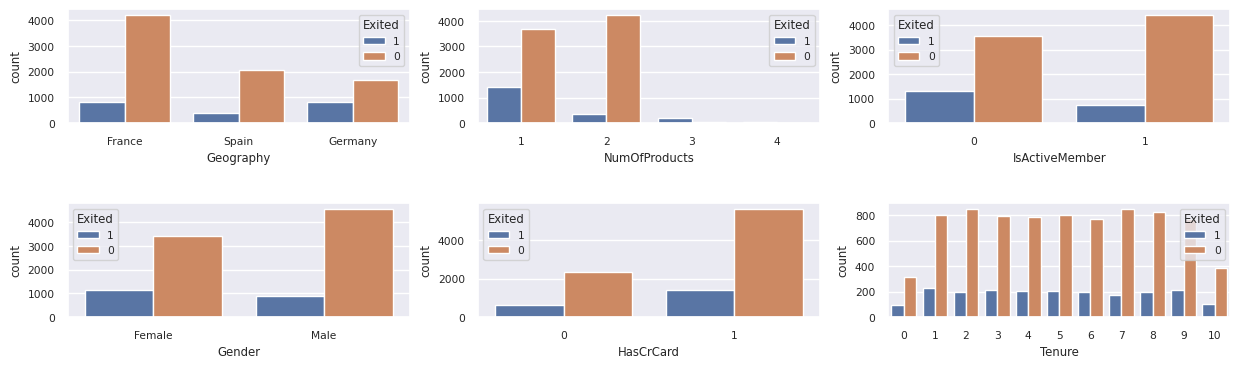

In [11]:
fig, axarr = plt.subplots(2,3, figsize=(15,4))
for ind, item in enumerate(attr_list):
    print(ind,item)
    sns.countplot(x = item, hue='Exited', data=df_clean, ax = axarr[ind%2][ind//2])
fig.subplots_adjust(hspace=0.7)

In [15]:
df_clean['Exited'] = df_clean['Exited'].astype(int)

StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 19, Finished, Available, Finished, False)

## **Distribution of numerical atributes**

StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 20, Finished, Available, Finished, False)

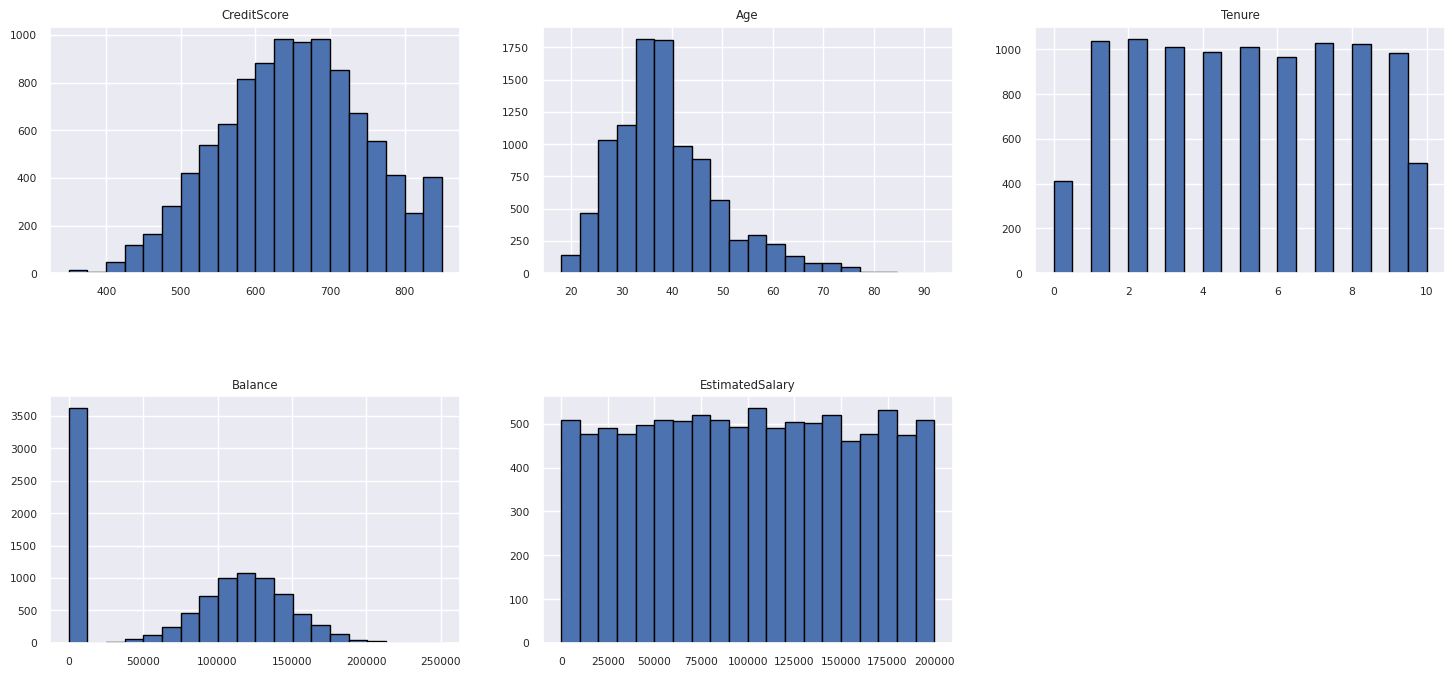

In [16]:
columns = df_num_columns.columns[: len(df_num_columns)]

fig = plt.figure()
fig.set_size_inches(18,8)
length = len(columns)

for i,j in itertools.zip_longest(columns, range(length)):
    plt.subplot((length//2), 3, j+1)
    plt.subplots_adjust(wspace=0.2, hspace=0.5)
    df_num_columns[i].hist(bins=20, edgecolor = 'black')
    plt.title(i)
plt.show()

## **Perform feature engineering**

To generate new attributes based on current atributes;

In [17]:
df_clean['Tenure']=df_clean['Tenure'].astype(int)
df_clean["NewTenure"] = df_clean["Tenure"]/df_clean["Age"]
df_clean["NewCreditsScore"]=pd.qcut(df_clean['CreditScore'],6, labels=[1,2,3,4,5,6])
df_clean["NewAgeScore"] = pd.qcut(df_clean['Age'],8, labels=[1,2,3,4,5,6,7,8])
df_clean["NewBalanceScore"] = pd.qcut(df_clean['Balance'].rank(method='first'),5, labels=[1,2,3,4,5])
df_clean["NewEstSalaryScore"] = pd.qcut(df_clean['EstimatedSalary'],10, labels=[1,2,3,4,5,6,7,8,9,10])

StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 22, Finished, Available, Finished, False)

In [18]:
# Código generado por Data Wrangler para pandas DataFrame

import pandas as pd

def clean_data(df_clean):
    # Columnas de codificación de acceso único: 'Gender', 'Geography'
    for column in ['Gender', 'Geography']:
        insert_loc = df_clean.columns.get_loc(column)
        df_clean = pd.concat([df_clean.iloc[:,:insert_loc], pd.get_dummies(df_clean.loc[:, [column]]), df_clean.iloc[:,insert_loc+1:]], axis=1)
    return df_clean

df_clean_1 = clean_data(df_clean.copy())
display(df_clean_1)

StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 36, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, eec8c02e-ae3e-401b-a3fd-a0b5e3f98705)

## Summary of observations from the exploratory data analysis
- Most of the customers are from France and Spain has the lowest churn rate comparing with Germany and France.
- Most of teh customers have a credit card.
- Customers who arent active have higher churn rate.
- Gender and Tenure dot seem to have impact on customers decision to close the bank account.

In [19]:
table_name = "df_clean"

sparkDF = spark.createDataFrame(df_clean_1)
sparkDF.write.mode("overwrite").format("delta").save(f"Tables/{table_name}")
print(f"Spark Dataframe saved to delta table: {table_name}")

StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 38, Finished, Available, Finished, False)

Spark Dataframe saved to delta table: df_clean


In [21]:
df = spark.sql("SELECT * FROM testing_lake.df_clean LIMIT 1000")
display(df)

StatementMeta(, 384741e2-1140-427a-b229-f0e80094cce3, 40, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 454daec8-fe65-4708-9720-7d291490309e)